# **YouTube Sentiment & Sarcasm Classifier**
This notebook documents the end-to-end machine learning pipeline for a specialized NLP model designed to analyze YouTube comment data. This model features a dual-output architecture capable of simultaneously predicting sentiment polarity and detecting sarcastic intent.
## Key Objectives


1.   Contextual Awareness: Train a Bidirectional LSTM (Long Short-Term Memory) network to capture long-range dependencies in informal, slang-heavy text.
2.   Sarcasm Mitigation: Implement a secondary output branch to flag ironic statements, preventing them from skewing the final sentiment score.
3.   Optimized Inference: Export a serialized Keras model and Pickle tokenizer for real-time deployment on Streamlit Cloud.
## Technical Pipeline


1.   **Data Preprocessing**: Cleaning HTML artifacts, handling emojis, and custom tokenization with a 20,000-word vocabulary.
2.   **Architecture Design**:


*   Embedding Layer: 64-dimensional dense vectors.
*   Bi-LSTM Layer: 64 units with 50% Dropout for regularization.
*   Dense Sentiment Head: 3-unit Softmax (Positive, Negative, Neutral).
*   Dense Sarcasm Head: 1-unit Sigmoid (Sarcastic vs. Sincere).
3.   **Training Strategy**: Binary Crossentropy and Sparse Categorical Crossentropy loss functions with Adam optimization.

















## Import required modules

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
import pickle
from googleapiclient.discovery import build
from google.colab import userdata
import re
from tensorflow.keras.models import load_model
from google.colab import userdata

## Download both sarcasm and youtube dataset

### downloading sarcasm dataset

In [2]:
# Install dependencies for downloading dataset from kaggle
!pip install kagglehub

In [3]:
import kagglehub

#Download the dataset directory
print("Downloading dataset")
dataset_path = kagglehub.dataset_download("danofer/sarcasm")
print(f"Dataset downloaded to: {dataset_path}")

#Load the CSV file using Pandas
target_file = "train-balanced-sarcasm.csv"
csv_path = os.path.join(dataset_path, target_file)

try:
    sarcasm_dataset = pd.read_csv(csv_path)
    print(f"\nSuccessfully loaded sarcasm_dataset")
except Exception as e:
    print(f"\nError reading the CSV: {e}")

100%|██████████| 216M/216M [00:01<00:00, 134MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/danofer/sarcasm/versions/4

Successfully loaded sarcasm_dataset


### downloading youtube comment sentiment dataset

In [4]:
from huggingface_hub import notebook_login

notebook_login()

In [5]:
df = pd.read_csv("hf://datasets/AmaanP314/youtube-comment-sentiment/youtube-comments-sentiment.csv")


## Preprocessing both the datasets

### Preprocessing sarcasm dataset

In [6]:
sarcasm_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010826 entries, 0 to 1010825
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   label           1010826 non-null  int64 
 1   comment         1010771 non-null  object
 2   author          1010826 non-null  object
 3   subreddit       1010826 non-null  object
 4   score           1010826 non-null  int64 
 5   ups             1010826 non-null  int64 
 6   downs           1010826 non-null  int64 
 7   date            1010826 non-null  object
 8   created_utc     1010826 non-null  object
 9   parent_comment  1010826 non-null  object
dtypes: int64(4), object(6)
memory usage: 77.1+ MB


In [7]:
sarcasm_dataset.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for th...


In [8]:
sarcasm_dataset.columns

Index(['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs',
       'date', 'created_utc', 'parent_comment'],
      dtype='object')

In [9]:

#Select only the comment and label columns
sarcasm_dataset_clean = sarcasm_dataset[['comment', 'label']].copy()

#Drop rows where the comment is missing (NaN)
print(f"Original row count: {len(sarcasm_dataset_clean)}")
sarcasm_dataset_clean.dropna(subset=['comment', 'label'], inplace=True)

#Ensure labels are integers (0 = Not Sarcastic, 1 = Sarcastic)
sarcasm_dataset_clean['label'] = sarcasm_dataset_clean['label'].astype(int)

#Drop duplicates
sarcasm_dataset_clean.drop_duplicates(subset=['comment'], inplace=True)
print(f"Cleaned row count: {len(sarcasm_dataset_clean)}")

Original row count: 1010826
Cleaned row count: 962293


### Preprocessing youtube comment dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032225 entries, 0 to 1032224
Data columns (total 12 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   CommentID        1032225 non-null  object
 1   VideoID          1032225 non-null  object
 2   VideoTitle       1032225 non-null  object
 3   AuthorName       1031594 non-null  object
 4   AuthorChannelID  1032225 non-null  object
 5   CommentText      1032225 non-null  object
 6   Sentiment        1032225 non-null  object
 7   Likes            1032225 non-null  int64 
 8   Replies          1032225 non-null  int64 
 9   PublishedAt      1032225 non-null  object
 10  CountryCode      1032225 non-null  object
 11  CategoryID       1032225 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 94.5+ MB


In [11]:
df.head()

,CommentID,VideoID,VideoTitle,AuthorName,AuthorChannelID,CommentText,Sentiment,Likes,Replies,PublishedAt,CountryCode,CategoryID
0,UgyRjrEdJIPrf68uND14AaABAg,mcY4M9gjtsI,They killed my friend.#tales #movie #shorts,@OneWhoWandered,UC_-UEXaBL1dqqUPGkDll49A,Anyone know what movie this is?,Neutral,0,2,2025-01-15 00:54:55,NZ,1
1,UgxXxEIySAwnMNw8D7N4AaABAg,2vuXcw9SZbA,Man Utd conceding first penalty at home in yea...,@chiefvon3068,UCZ1LcZESjYqzaQRhjdZJFwg,The fact they're holding each other back while...,Positive,0,0,2025-01-13 23:51:46,AU,17
2,UgxB0jh2Ur41mcXr5IB4AaABAg,papg2tsoFzg,Welcome to Javascript Course,@Abdulla-ip8qr,UCWBK35w5Swy1iF5xIbEyw3A,waiting next video will be?,Neutral,1,0,2020-07-06 13:18:16,IN,27
3,UgwMOh95MfK0GuXLLrF4AaABAg,31KTdfRH6nY,Building web applications in Java with Spring ...,@finnianthehuman,UCwQ2Z03nOcMxWozBb_Cv66w,Thanks for the great video.\n\nI don't underst...,Neutral,0,1,2024-09-18 12:04:12,US,27
4,UgxJuUe5ysG8OSbABAl4AaABAg,-hV6aeyPHPA,After a new engine her car dies on her way hom...,@ryoutubeplaylistb6137,UCTTcJ0tsAKQokmHB2qVb1qQ,Good person helping good people.\nThis is how ...,Positive,3,1,2025-01-10 19:39:03,US,2


In [12]:
df.columns

Index(['CommentID', 'VideoID', 'VideoTitle', 'AuthorName', 'AuthorChannelID',
       'CommentText', 'Sentiment', 'Likes', 'Replies', 'PublishedAt',
       'CountryCode', 'CategoryID'],
      dtype='object')

In [13]:
df = df[['CommentText', 'Sentiment']]

In [14]:
df=df.dropna()

In [15]:
df = df.drop_duplicates(subset=['CommentText'])

In [16]:
df.shape

(989881, 2)

In [17]:
print(df['Sentiment'].value_counts())

Sentiment
Negative    339489
Neutral     326276
Positive    324116
Name: count, dtype: int64


## Training sarcasm detection model



### Setting the tokenizer

In [18]:

#Configuration
VOCAB_SIZE = 20000
MAX_LENGTH = 100
TRUNC_TYPE = 'post'
PADDING_TYPE = 'post'
OOV_TOK = "<OOV>"

#Initialize and Fit the Tokenizer
print("Fitting Tokenizer")
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOK)
tokenizer.fit_on_texts(sarcasm_dataset_clean['comment'])

#Convert Text to Number Sequences
sequences = tokenizer.texts_to_sequences(sarcasm_dataset_clean['comment'])

#Pad the Sequences so they are all exactly exactly 100 numbers long
X_padded = pad_sequences(sequences, maxlen=MAX_LENGTH, padding=PADDING_TYPE, truncating=TRUNC_TYPE)

#Extract the Labels
y_labels = sarcasm_dataset_clean['label'].values

#Save the Tokenizer
with open('sarcasm_tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Tokenizer saved as 'sarcasm_tokenizer.pkl'")

Fitting Tokenizer
Tokenizer saved as 'sarcasm_tokenizer.pkl'


### Splitting into training and testing data

In [19]:
#Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")


Training data shape: (769834, 100)
Testing data shape: (192459, 100)
Training labels shape: (769834,)


In [20]:

#Setting Parameters
VOCAB_SIZE = 20000
MAX_LENGTH = 100
EMBEDDING_DIM = 64

print("Building the Bi-LSTM Sarcasm Model")

sarcasm_model = Sequential([
    #Turns word numbers into dense vectors of meaning
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LENGTH),

    #Reads the sentence forwards AND backwards for context
    Bidirectional(LSTM(64, return_sequences=False)),

    #Randomly turns off 50% of neurons to prevent overfitting
    Dropout(0.5),

    #A single neuron that outputs a probability from 0.0 to 1.0
    Dense(1, activation='sigmoid')
])

# Compile the model
sarcasm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# View the architecture
sarcasm_model.summary()

Building the Bi-LSTM Sarcasm Model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
#Setup Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Starting training")

history = sarcasm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

print("Training completed")

#Saving the model
sarcasm_model.save("sarcasm_detector_bilstm.keras")
print("Model saved as 'sarcasm_detector_bilstm.keras'")

Starting training
Epoch 1/10
6015/6015 ━━━━━━━━━━━━━━━━━━━━ 100s 15ms/step - accuracy: 0.7017 - loss: 0.5695 - val_accuracy: 0.7148 - val_loss: 0.5535
Epoch 2/10
6015/6015 ━━━━━━━━━━━━━━━━━━━━ 112s 19ms/step - accuracy: 0.7279 - loss: 0.5373 - val_accuracy: 0.7174 - val_loss: 0.5501
Epoch 3/10
6015/6015 ━━━━━━━━━━━━━━━━━━━━ 93s 15ms/step - accuracy: 0.7422 - loss: 0.5171 - val_accuracy: 0.7161 - val_loss: 0.5531
Epoch 4/10
6015/6015 ━━━━━━━━━━━━━━━━━━━━ 91s 15ms/step - accuracy: 0.7553 - loss: 0.4974 - val_accuracy: 0.7149 - val_loss: 0.5664
Epoch 5/10
6015/6015 ━━━━━━━━━━━━━━━━━━━━ 95s 16ms/step - accuracy: 0.7680 - loss: 0.4763 - val_accuracy: 0.7127 - val_loss: 0.5782
Training completed
Model saved as 'sarcasm_detector_bilstm.keras'


### Validation

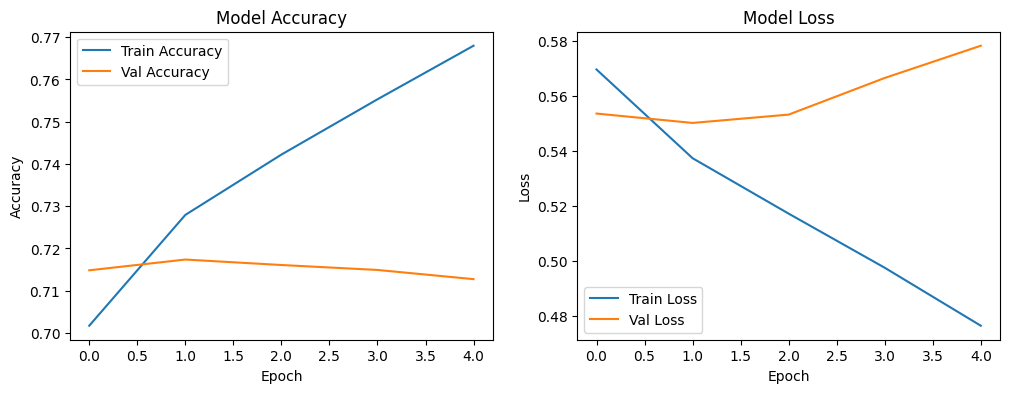

In [22]:
import matplotlib.pyplot as plt

# Plotting Training vs Validation Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

6015/6015 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step

PERFORMANCE REPORT
              precision    recall  f1-score   support

     Sincere       0.70      0.76      0.73     95639
   Sarcastic       0.74      0.67      0.71     96820

    accuracy                           0.72    192459
   macro avg       0.72      0.72      0.72    192459
weighted avg       0.72      0.72      0.72    192459



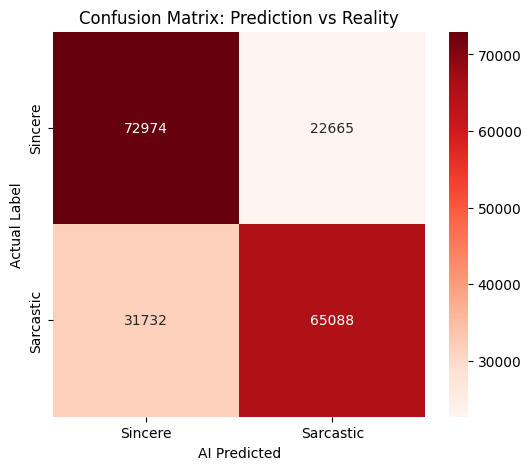

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# 1. Get the raw predictions (probabilities)
y_pred_probs = sarcasm_model.predict(X_test)

# 2. Convert probabilities to binary (0 or 1)
# We use 0.5 as the threshold for a standard sarcasm detector
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Print the Classification Report
print("\n" + "="*60)
print("PERFORMANCE REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Sincere', 'Sarcastic']))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Sincere', 'Sarcastic'],
            yticklabels=['Sincere', 'Sarcastic'])
plt.title('Confusion Matrix: Prediction vs Reality')
plt.xlabel('AI Predicted')
plt.ylabel('Actual Label')
plt.show()

## Using the sarcasm prediction model to predict sarcasm in youtube dataset

In [27]:
import pandas as pd
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

text_column_name = 'CommentText'

#Loading the Sarcasm Model and the Tokenizer
print("Loading Model and Tokenizer")
sarcasm_model = load_model("sarcasm_detector_bilstm.keras")

with open('sarcasm_tokenizer.pkl', 'rb') as handle:
    sarcasm_tokenizer = pickle.load(handle)

#Preprocess the YouTube comments
print("Tokenizing and padding YouTube data")
comments = df[text_column_name].astype(str)
MAX_LENGTH = 100
sequences = sarcasm_tokenizer.texts_to_sequences(comments)
X_yt_padded = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

#Run the Predictions
print("Detecting sarcasm from the comments")
sarcasm_probs = sarcasm_model.predict(X_yt_padded)

#Inject the new features into the dataset
df['sarcasm_prob'] = sarcasm_probs

df['is_sarcastic'] = (df['sarcasm_prob'] > 0.60).astype(int)

Loading Model and Tokenizer
Tokenizing and padding YouTube data
Detecting sarcasm from the comments
30934/30934 ━━━━━━━━━━━━━━━━━━━━ 203s 7ms/step


## Checking the newly added columns in df

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 989881 entries, 0 to 1032224
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   CommentText   989881 non-null  object 
 1   Sentiment     989881 non-null  object 
 2   sarcasm_prob  989881 non-null  float32
 3   is_sarcastic  989881 non-null  int64  
dtypes: float32(1), int64(1), object(2)
memory usage: 34.0+ MB


In [ ]:
print("TOP 5 SARCASTIC COMMENTS (is_sarcastic = 1)")
print("-" * 60)
text_col='CommentText'
sarcastic_samples = df[df['is_sarcastic'] == 1]
for index, row in sarcastic_samples.head(5).iterrows():
    print(f"Prob: {row['sarcasm_prob']:.2f} | {row[text_col]}")

print("\nTOP 5 NON-SARCASTIC COMMENTS (is_sarcastic = 0)")
print("-" * 60)
non_sarcastic_samples = df[df['is_sarcastic'] == 0]
for index, row in non_sarcastic_samples.head(5).iterrows():
    print(f"Prob: {row['sarcasm_prob']:.2f} | {row[text_col]}")

TOP 5 SARCASTIC COMMENTS (is_sarcastic = 1)
------------------------------------------------------------
Prob: 0.71 | Thank God we don’t have to listen to his drivel anymore
Prob: 0.78 | What a classy idea for content.  Maybe it'll trend and brighten peoples days around the world, and give them a reason to go on.  You're an inspiration.
Prob: 0.74 | Bro playes gta5 a lot😂
Prob: 0.65 | I didn't take Spanish, but southern translates-  heard CLEARLY the frustrated "this m'FER!" 😂
Prob: 0.74 | Great job as always.

TOP 5 NON-SARCASTIC COMMENTS (is_sarcastic = 0)
------------------------------------------------------------
Prob: 0.29 | Anyone know what movie this is?
Prob: 0.29 | The fact they're holding each other back while equally being most aggressive 😂😂
Prob: 0.51 | waiting next video will be?
Prob: 0.30 | Thanks for the great video.

I don't understand why the DB continues to be accesible through port 8080 when the local machine connects to the docker container through port 5432? Or, 

## Model training

### Dropping missing values and mapping sentiment

In [28]:
#Drop missing values
df = df.dropna(subset=['CommentText', 'Sentiment', 'is_sarcastic'])

In [29]:
sentiment_mapping = {
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
}

df['Sentiment'] = df['Sentiment'].map(sentiment_mapping)

### Setting the tokenizer

In [30]:
#Extract features and targets
texts = df['CommentText'].astype(str)
y_sentiment = df['Sentiment'].values
y_sarcasm = df['is_sarcastic'].values

#Create the Final Production Tokenizer
VOCAB_SIZE = 20000
MAX_LENGTH = 100

print("Fitting Production Tokenizer...")
final_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
final_tokenizer.fit_on_texts(texts)

# Saving the Tokenizer
with open('final_production_tokenizer.pkl', 'wb') as handle:
    pickle.dump(final_tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

#Convert text to padded sequences
X_seq = final_tokenizer.texts_to_sequences(texts)
X_padded = pad_sequences(X_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

Fitting Production Tokenizer...


### Splitting into training and testing data

In [31]:
stratify_keys = df['Sentiment'].astype(str) + "_" + df['is_sarcastic'].astype(str)

X_train, X_test, y_train_sent, y_test_sent, y_train_sarc, y_test_sarc = train_test_split(
    X_padded,
    y_sentiment,
    y_sarcasm,
    test_size=0.2,
    random_state=42,
    stratify=stratify_keys
)

In [32]:
print(f"Training shapes -> X: {X_train.shape}, Sentiment Y: {y_train_sent.shape}, Sarcasm Y: {y_train_sarc.shape}")

Training shapes -> X: (791904, 100), Sentiment Y: (791904,), Sarcasm Y: (791904,)


### Building the model

In [33]:
input_layer = Input(shape=(MAX_LENGTH,), name='text_input')
embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=64)(input_layer)

shared_lstm = Bidirectional(LSTM(64, return_sequences=False))(embedding)
shared_dropout = Dropout(0.5)(shared_lstm)

sentiment_head = Dense(3, activation='softmax', name='sentiment_output')(shared_dropout)

sarcasm_head = Dense(1, activation='sigmoid', name='sarcasm_output')(shared_dropout)

multi_task_model = Model(inputs=input_layer, outputs=[sentiment_head, sarcasm_head])

multi_task_model.compile(
    optimizer='adam',
    loss={
        'sentiment_output': 'sparse_categorical_crossentropy',
        'sarcasm_output': 'binary_crossentropy'
    },
    loss_weights={
        'sentiment_output': 1.0,
        'sarcasm_output': 0.5
    },

    metrics={
        'sentiment_output': 'accuracy',
        'sarcasm_output': 'accuracy'
    }
)

multi_task_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 64)   │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     66,048 │ embedding_1[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 3)         │        387 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sarcasm_output      │ (None, 1)         │        129 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,346,564 (5.14 MB)

 Trainable params: 1,346,564 (5.14 MB)

 Non-trainable params: 0 (0.00 B)

### Model training

In [34]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = multi_task_model.fit(
    x=X_train,
    y={
        'sentiment_output': y_train_sent,
        'sarcasm_output': y_train_sarc
    },
    validation_data=(
        X_test,
        {
            'sentiment_output': y_test_sent,
            'sarcasm_output': y_test_sarc
        }
    ),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)

print("\nTraining Complete.")

# Saving the final production model
multi_task_model.save("youtube_production_model.keras")
print("Master model saved as 'youtube_production_model.keras'")

Epoch 1/15
12374/12374 ━━━━━━━━━━━━━━━━━━━━ 203s 16ms/step - loss: 0.8567 - sarcasm_output_accuracy: 0.9105 - sarcasm_output_loss: 0.2180 - sentiment_output_accuracy: 0.6713 - sentiment_output_loss: 0.7477 - val_loss: 0.7739 - val_sarcasm_output_accuracy: 0.9357 - val_sarcasm_output_loss: 0.1565 - val_sentiment_output_accuracy: 0.6948 - val_sentiment_output_loss: 0.6957
Epoch 2/15
12374/12374 ━━━━━━━━━━━━━━━━━━━━ 205s 17ms/step - loss: 0.7479 - sarcasm_output_accuracy: 0.9454 - sarcasm_output_loss: 0.1365 - sentiment_output_accuracy: 0.7058 - sentiment_output_loss: 0.6796 - val_loss: 0.7428 - val_sarcasm_output_accuracy: 0.9480 - val_sarcasm_output_loss: 0.1279 - val_sentiment_output_accuracy: 0.7028 - val_sentiment_output_loss: 0.6789
Epoch 3/15
12374/12374 ━━━━━━━━━━━━━━━━━━━━ 202s 16ms/step - loss: 0.7001 - sarcasm_output_accuracy: 0.9577 - sarcasm_output_loss: 0.1079 - sentiment_output_accuracy: 0.7226 - sentiment_output_loss: 0.6462 - val_loss: 0.7382 - val_sarcasm_output_accuracy

### Validation

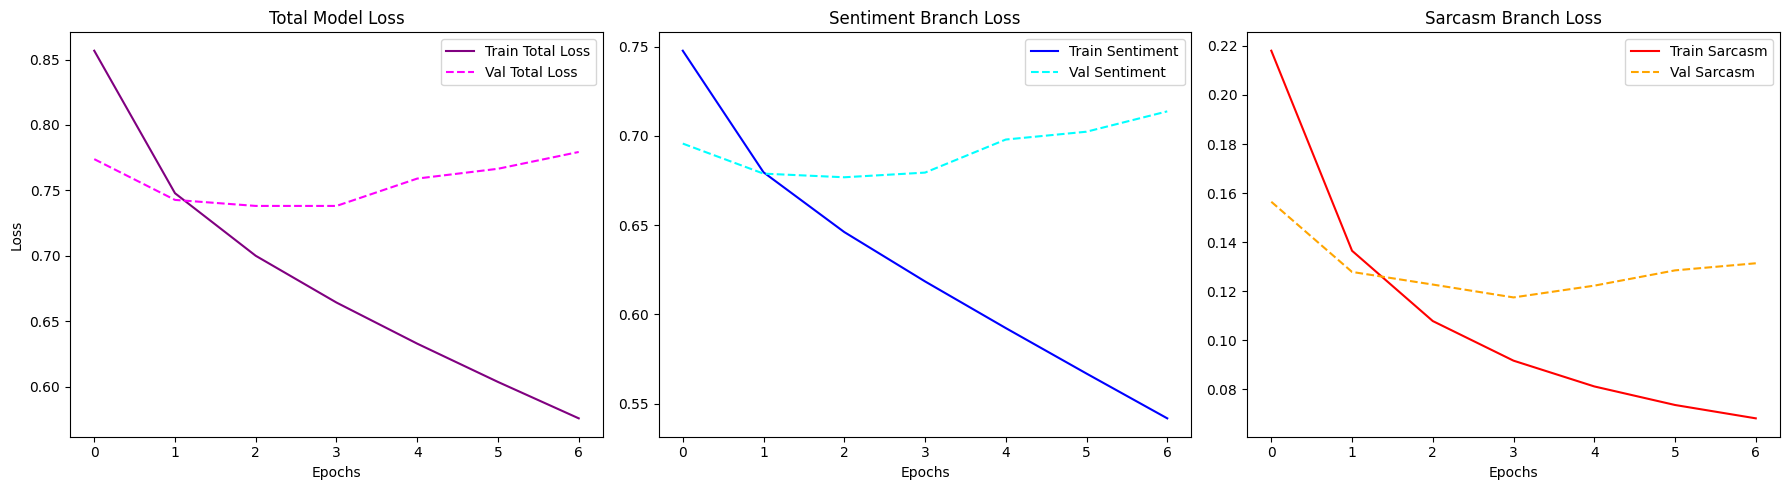

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# TRAINING VS VALIDATION LOSS CURVES

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Combined Loss
axes[0].plot(history.history['loss'], label='Train Total Loss', color='purple')
axes[0].plot(history.history['val_loss'], label='Val Total Loss', color='magenta', linestyle='--')
axes[0].set_title('Total Model Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Sentiment Branch Loss
axes[1].plot(history.history['sentiment_output_loss'], label='Train Sentiment', color='blue')
axes[1].plot(history.history['val_sentiment_output_loss'], label='Val Sentiment', color='cyan', linestyle='--')
axes[1].set_title('Sentiment Branch Loss')
axes[1].set_xlabel('Epochs')
axes[1].legend()

# Sarcasm Branch Loss
axes[2].plot(history.history['sarcasm_output_loss'], label='Train Sarcasm', color='red')
axes[2].plot(history.history['val_sarcasm_output_loss'], label='Val Sarcasm', color='orange', linestyle='--')
axes[2].set_title('Sarcasm Branch Loss')
axes[2].set_xlabel('Epochs')
axes[2].legend()

plt.tight_layout()
plt.show()

6187/6187 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step

SENTIMENT CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.71      0.73      0.72     67898
     Neutral       0.65      0.67      0.66     65255
    Positive       0.77      0.72      0.75     64824

    accuracy                           0.71    197977
   macro avg       0.71      0.71      0.71    197977
weighted avg       0.71      0.71      0.71    197977


SARCASM CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Sincere       0.96      0.98      0.97    165565
   Sarcastic       0.90      0.81      0.85     32412

    accuracy                           0.95    197977
   macro avg       0.93      0.90      0.91    197977
weighted avg       0.95      0.95      0.95    197977



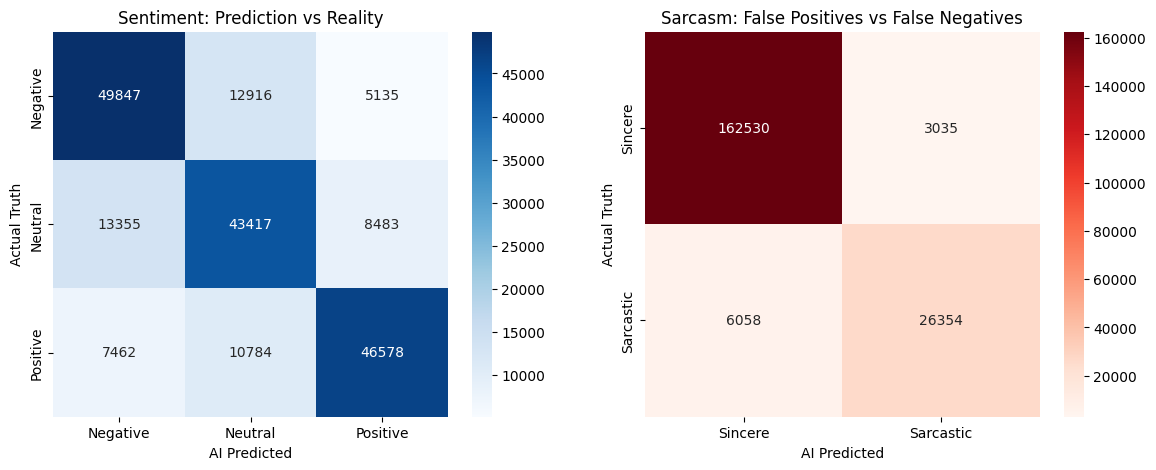

In [36]:

# RUN MODEL ON THE TEST SET
predictions = multi_task_model.predict(X_test)

# Convert Softmax probabilities to class integers
y_pred_sent = np.argmax(predictions[0], axis=1)

# Convert Sigmoid probabilities to binary
y_pred_sarc = (predictions[1] > 0.5).astype(int).flatten()

# THE CLASSIFICATION REPORTS
print("\n" + "="*55)
print("SENTIMENT CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_test_sent, y_pred_sent, target_names=["Negative", "Neutral", "Positive"]))

print("\n" + "="*55)
print("SARCASM CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_test_sarc, y_pred_sarc, target_names=["Sincere", "Sarcastic"]))



# CONFUSION MATRICES
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment Matrix
sns.heatmap(confusion_matrix(y_test_sent, y_pred_sent), annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"], ax=axes[0])
axes[0].set_title("Sentiment: Prediction vs Reality")
axes[0].set_xlabel("AI Predicted")
axes[0].set_ylabel("Actual Truth")

# Sarcasm Matrix
sns.heatmap(confusion_matrix(y_test_sarc, y_pred_sarc), annot=True, fmt='d', cmap='Reds',
            xticklabels=["Sincere", "Sarcastic"],
            yticklabels=["Sincere", "Sarcastic"], ax=axes[1])
axes[1].set_title("Sarcasm: False Positives vs False Negatives")
axes[1].set_xlabel("AI Predicted")
axes[1].set_ylabel("Actual Truth")

plt.show()

## Loading the model and testing with sample example

In [37]:
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

#Loading the model and the tokenizer
print("Loading Backend Artifacts...")
prod_model = load_model("youtube_production_model.keras")

with open('final_production_tokenizer.pkl', 'rb') as handle:
    prod_tokenizer = pickle.load(handle)

MAX_LENGTH = 100

#Defining the Mapping Dictionaries
sentiment_decoder = {0: "Negative", 1: "Neutral", 2: "Positive"}

# The prediction function
def analyze_comment(text):
    # Preprocessing
    seq = prod_tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

    # Model Prediction
    predictions = prod_model.predict(padded, verbose=0)
    sentiment_probs = predictions[0][0]
    sarcasm_prob = predictions[1][0][0]

    # Extract Raw Decisions
    raw_sentiment_int = int(np.argmax(sentiment_probs))
    is_sarcastic = bool(sarcasm_prob > 0.60)

    # keeping normal comments as standard and sarcasm will be labelled below
    final_sentiment_int = raw_sentiment_int
    logic_applied = "Standard"

    # If sarcasm is detected, immediately force the final sentiment to Negative
    if is_sarcastic:
        final_sentiment_int = 0
        logic_applied = "Sarcasm Detected -> Forced Negative"

    # Output
    return {
        "text": text,
        "raw_sentiment": sentiment_decoder[raw_sentiment_int],
        "is_sarcastic": is_sarcastic,
        "final_sentiment": sentiment_decoder[final_sentiment_int],
        "logic_applied": logic_applied
    }


# Testing with sample examples
print("\n--- Running Tests ---")

test_comments = [
    "This video was incredibly helpful, thank you so much!",
    "Oh wow, another 20 minute video to explain a 2 minute concept. Brilliant.",
    "This is the absolute worst tutorial I have ever watched. Pure garbage.",
    "Oh sure, because spending $500 on a keyboard totally makes you a better coder. Masterpiece of a video."
]

for comment in test_comments:
    result = analyze_comment(comment)
    print(f"\nComment: '{result['text']}'")
    print(f"Raw Model Guess : {result['raw_sentiment']}")
    print(f"Sarcasm Flag    : {result['is_sarcastic']}")
    print(f"FINAL DECISION  : {result['final_sentiment']} [{result['logic_applied']}]")

Loading Backend Artifacts...

--- Running Tests ---

Comment: 'This video was incredibly helpful, thank you so much!'
Raw Model Guess : Positive
Sarcasm Flag    : True
FINAL DECISION  : Negative [Sarcasm Detected -> Forced Negative]

Comment: 'Oh wow, another 20 minute video to explain a 2 minute concept. Brilliant.'
Raw Model Guess : Positive
Sarcasm Flag    : True
FINAL DECISION  : Negative [Sarcasm Detected -> Forced Negative]

Comment: 'This is the absolute worst tutorial I have ever watched. Pure garbage.'
Raw Model Guess : Negative
Sarcasm Flag    : False
FINAL DECISION  : Negative [Standard]

Comment: 'Oh sure, because spending $500 on a keyboard totally makes you a better coder. Masterpiece of a video.'
Raw Model Guess : Negative
Sarcasm Flag    : True
FINAL DECISION  : Negative [Sarcasm Detected -> Forced Negative]


## Fetching comments and likes of those comments using the YouTube DataV3 api

In [38]:
#fetch the API key
try:
    API_KEY = userdata.get('YOUTUBE_API_KEY')
except userdata.SecretNotFoundError:
    print("YOUTUBE_API_KEY not found.")

#Function to extract the ID from ANY YouTube URL
def extract_video_id(url):
    regex = r"(?:youtube\.com\/(?:[^\/]+\/.+\/|(?:v|e(?:mbed)?)\/|.*[?&]v=)|youtu\.be\/)([^\"&?\/\s]{11})"
    match = re.search(regex, url)
    if match:
        return match.group(1)
    else:
        raise ValueError("Could not find a valid YouTube Video ID in the provided URL.")

#Fetching the comments and likes
def get_youtube_comments_with_likes(video_id, api_key, max_comments=500):
    print(f"Fetching up to {max_comments} substantive comments for video ID: {video_id}...")

    youtube = build('youtube', 'v3', developerKey=api_key)
    comments = []
    next_page_token = None
    total_fetched = 0

    #loop to fetch multiple pages until max_comments is reached
    while len(comments) < max_comments:
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=100,
            order="relevance",
            pageToken=next_page_token
        )

        try:
            response = request.execute()
        except Exception as e:
            print(f"API Error: {e}")
            break

        items = response.get('items', [])
        total_fetched += len(items)

        for item in items:
            snippet = item['snippet']['topLevelComment']['snippet']
            raw_text = snippet['textDisplay']

            #clean html tags
            clean_text = re.sub(r'<.*?>', ' ', raw_text)

            #Skip short/spam comments
            if len(clean_text.split()) < 5:
                continue

            #obtain the like count
            like_count = int(snippet.get('likeCount', 0))

            comments.append({"text": clean_text, "likes": like_count})

            #stop if we reached the desired amount
            if len(comments) >= max_comments:
                break

        #get the token for the next page
        next_page_token = response.get('nextPageToken')

        #break the loop if there are no more comments to fetch
        if not next_page_token:
            print("Reached the end of the comment section.")
            break

    print(f"API pulled {total_fetched} total comments to find {len(comments)} valid ones.")
    return comments

#urls for 2 videos to test
YOUTUBE_URL = "https://www.youtube.com/watch?v=1L2ef1CP-yw" #good video
YOUTUBE_URL1 = "https://www.youtube.com/watch?v=eqkbs5Z3y-M&t=276s" #bad video

try:
    #extract the ID
    VIDEO_ID = extract_video_id(YOUTUBE_URL)

    #Fetch the comments
    scraped_data = get_youtube_comments_with_likes(VIDEO_ID, API_KEY, max_comments=500)

    if scraped_data:
        print("-" * 50)
        print(f"Successfully scraped {len(scraped_data)} substantive comments.")
        print("-" * 50)
        print(f"Sample Comment 1: {scraped_data[0]['text'][:100]}... [Likes: {scraped_data[0]['likes']}]")
        if len(scraped_data) > 1:
            print(f"Sample Comment 2: {scraped_data[1]['text'][:100]}... [Likes: {scraped_data[1]['likes']}]")

except ValueError as e:
    print(f"Error: {e}")

Fetching up to 500 substantive comments for video ID: 1L2ef1CP-yw...
API pulled 600 total comments to find 500 valid ones.
--------------------------------------------------
Successfully scraped 500 substantive comments.
--------------------------------------------------
Sample Comment 1: No joke, this is the old YouTube.  Not over produced stuff, but a normal guy having fun and doing Sc... [Likes: 47898]
Sample Comment 2: This kind of thing is why YouTube exists.... [Likes: 41027]


## Predicting the sentiment and sarcasm values of the comments and genrating report

In [39]:
import pandas as pd
import html

def generate_video_report(raw_comments, weight_volume=0.3, weight_likes=0.7):
    print(f"\n--- Starting Sentiment Analysis on {len(raw_comments)} pre-filtered comments ---")

    if not raw_comments:
        return "No comments provided to analyze."

    positives = []
    negatives = []
    neutrals = []

    total_pos_likes, total_neg_likes = 0, 0
    total_pos_count, total_neg_count = 0, 0
    total_sarcastic = 0

    # Process Data
    for item in raw_comments:
        # Clean the HTML entities BEFORE it goes to the AI
        text = html.unescape(item['text'])
        likes = item['likes']

        # predicting using model
        ai_result = analyze_comment(text)
        final_sentiment = ai_result['final_sentiment']
        is_sarc = ai_result['is_sarcastic']

        if is_sarc:
            total_sarcastic += 1

        if final_sentiment == "Positive":
            positives.append({"text": text, "likes": likes, "is_sarcastic": is_sarc})
            total_pos_count += 1
            total_pos_likes += likes

        elif final_sentiment == "Negative":
            negatives.append({"text": text, "likes": likes, "is_sarcastic": is_sarc})
            total_neg_count += 1
            total_neg_likes += likes

        elif final_sentiment == "Neutral":
            neutrals.append({"text": text, "likes": likes, "is_sarcastic": is_sarc})

    # Weighted Math for calculating overall positive or negative percentage
    total_polar_comments = total_pos_count + total_neg_count
    total_polar_likes = total_pos_likes + total_neg_likes
    total_analyzed = total_polar_comments + len(neutrals)

    count_pos_pct = (total_pos_count / total_polar_comments * 100) if total_polar_comments > 0 else 50.0
    like_pos_pct = (total_pos_likes / total_polar_likes * 100) if total_polar_likes > 0 else count_pos_pct

    overall_positive_score = (count_pos_pct * weight_volume) + (like_pos_pct * weight_likes)
    overall_negative_score = 100 - overall_positive_score

    # Sorting
    positives = sorted(positives, key=lambda x: x['likes'], reverse=True)[:10]
    negatives = sorted(negatives, key=lambda x: x['likes'], reverse=True)[:10]
    neutrals = sorted(neutrals, key=lambda x: x['likes'], reverse=True)[:10]

    #Output
    print("\n" + "="*50)
    print(f" FINAL SENTIMENT REPORT")
    print("="*50)
    print(f"Score Split      : {weight_volume*100}% Volume / {weight_likes*100}% Likes")
    print(f"Final Verdict    : {overall_positive_score:.1f}% Positive | {overall_negative_score:.1f}% Negative")
    print(f"Total Analyzed   : {total_analyzed} (Polar: {total_polar_comments}, Neutral: {len(neutrals)})")

    # Display the global sarcasm metric
    sarcasm_pct = (total_sarcastic / total_analyzed) * 100
    print(f"Total Sarcastic  : {total_sarcastic} ({sarcasm_pct:.1f}% of all comments)")

    print("\n TOP POSITIVE COMMENTS:")
    for c in positives[:3]:
        sarc_flag = "YES" if c['is_sarcastic'] else "NO "
        print(f"- [Sarcasm: {sarc_flag}] [Likes: {c['likes']:<4}] {c['text'][:80]}...")

    print("\n TOP NEGATIVE COMMENTS:")
    for c in negatives[:3]:
        sarc_flag = "YES" if c['is_sarcastic'] else "NO "
        print(f"- [Sarcasm: {sarc_flag}] [Likes: {c['likes']:<4}] {c['text'][:80]}...")

    print("\n TOP NEUTRAL COMMENTS:")
    for c in neutrals[:3]:
        sarc_flag = "YES" if c['is_sarcastic'] else "NO "
        print(f"- [Sarcasm: {sarc_flag}] [Likes: {c['likes']:<4}] {c['text'][:80]}...")

    return {
        "pos_score": overall_positive_score,
        "neg_score": overall_negative_score,
        "total_sarcastic": total_sarcastic,
        "sarcasm_pct": sarcasm_pct,
        "top_pos": positives,
        "top_neg": negatives,
        "top_neu": neutrals
    }

report = generate_video_report(scraped_data)



--- Starting Sentiment Analysis on 500 pre-filtered comments ---

 FINAL SENTIMENT REPORT
Score Split      : 30.0% Volume / 70.0% Likes
Final Verdict    : 68.9% Positive | 31.1% Negative
Total Analyzed   : 500 (Polar: 349, Neutral: 10)
Total Sarcastic  : 43 (8.6% of all comments)

 TOP POSITIVE COMMENTS:
- [Sarcasm: NO ] [Likes: 47898] No joke, this is the old YouTube.  Not over produced stuff, but a normal guy hav...
- [Sarcasm: NO ] [Likes: 19317] This is how I like experiments on youtube. No nonsense, no 5 minutes blabla, jus...
- [Sarcasm: NO ] [Likes: 6694] "This experiment is done"  You earned a ton of fans with this experiment. Thanks...

 TOP NEGATIVE COMMENTS:
- [Sarcasm: NO ] [Likes: 41027] This kind of thing is why YouTube exists....
- [Sarcasm: YES] [Likes: 2907] Amazing, thank you for making this. It will solve so many family fights on the b...
- [Sarcasm: NO ] [Likes: 1786] Matthias gives the answers everybody wants to know on the questions nobody asked...

 TOP NEUTRAL 

In [ ]:
#fetch the API key
try:
    API_KEY = userdata.get('YOUTUBE_API_KEY')
except userdata.SecretNotFoundError:
    print("YOUTUBE_API_KEY not found.")

#Function to extract the ID from ANY YouTube URL
def extract_video_id(url):
    regex = r"(?:youtube\.com\/(?:[^\/]+\/.+\/|(?:v|e(?:mbed)?)\/|.*[?&]v=)|youtu\.be\/)([^\"&?\/\s]{11})"
    match = re.search(regex, url)
    if match:
        return match.group(1)
    else:
        raise ValueError("Could not find a valid YouTube Video ID in the provided URL.")

#Fetching the comments and likes
def get_youtube_comments_with_likes(video_id, api_key, max_comments=500):
    print(f"Fetching up to {max_comments} substantive comments for video ID: {video_id}...")

    youtube = build('youtube', 'v3', developerKey=api_key)
    comments = []
    next_page_token = None
    total_fetched = 0

    #loop to fetch multiple pages until max_comments is reached
    while len(comments) < max_comments:
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=100,
            order="relevance",
            pageToken=next_page_token
        )

        try:
            response = request.execute()
        except Exception as e:
            print(f"API Error: {e}")
            break

        items = response.get('items', [])
        total_fetched += len(items)

        for item in items:
            snippet = item['snippet']['topLevelComment']['snippet']
            raw_text = snippet['textDisplay']

            #clean html tags
            clean_text = re.sub(r'<.*?>', ' ', raw_text)

            #Skip short/spam comments
            if len(clean_text.split()) < 5:
                continue

            #obtain the like count
            like_count = int(snippet.get('likeCount', 0))

            comments.append({"text": clean_text, "likes": like_count})

            #stop if we reached the desired amount
            if len(comments) >= max_comments:
                break

        #get the token for the next page
        next_page_token = response.get('nextPageToken')

        #break the loop if there are no more comments to fetch
        if not next_page_token:
            print("Reached the end of the comment section.")
            break

    print(f"API pulled {total_fetched} total comments to find {len(comments)} valid ones.")
    return comments

#urls for 2 videos to test
YOUTUBE_URL = "https://www.youtube.com/watch?v=1L2ef1CP-yw" #good video
YOUTUBE_URL1 = "https://www.youtube.com/watch?v=eqkbs5Z3y-M&t=276s" #bad video

try:
    #extract the ID
    VIDEO_ID = extract_video_id(YOUTUBE_URL)

    #Fetch the comments
    scraped_data = get_youtube_comments_with_likes(VIDEO_ID, API_KEY, max_comments=500)

    if scraped_data:
        print("-" * 50)
        print(f"Successfully scraped {len(scraped_data)} substantive comments.")
        print("-" * 50)
        print(f"Sample Comment 1: {scraped_data[0]['text'][:100]}... [Likes: {scraped_data[0]['likes']}]")
        if len(scraped_data) > 1:
            print(f"Sample Comment 2: {scraped_data[1]['text'][:100]}... [Likes: {scraped_data[1]['likes']}]")

except ValueError as e:
    print(f"Error: {e}")

Fetching up to 500 substantive comments for video ID: 1L2ef1CP-yw...
API pulled 600 total comments to find 500 valid ones.
--------------------------------------------------
Successfully scraped 500 substantive comments.
--------------------------------------------------
Sample Comment 1: No joke, this is the old YouTube.  Not over produced stuff, but a normal guy having fun and doing Sc... [Likes: 47898]
Sample Comment 2: This kind of thing is why YouTube exists.... [Likes: 41027]


In [42]:
import pandas as pd
import html

def generate_video_report(raw_comments, weight_volume=0.3, weight_likes=0.7):
    print(f"\n--- Starting Sentiment Analysis on {len(raw_comments)} pre-filtered comments ---")

    if not raw_comments:
        return "No comments provided to analyze."

    positives = []
    negatives = []
    neutrals = []

    total_pos_likes, total_neg_likes = 0, 0
    total_pos_count, total_neg_count = 0, 0
    total_sarcastic = 0

    # Process Data
    for item in raw_comments:
        # Clean the HTML entities BEFORE it goes to the AI
        text = html.unescape(item['text'])
        likes = item['likes']

        # predicting using model
        ai_result = analyze_comment(text)
        final_sentiment = ai_result['final_sentiment']
        is_sarc = ai_result['is_sarcastic']

        if is_sarc:
            total_sarcastic += 1

        if final_sentiment == "Positive":
            positives.append({"text": text, "likes": likes, "is_sarcastic": is_sarc})
            total_pos_count += 1
            total_pos_likes += likes

        elif final_sentiment == "Negative":
            negatives.append({"text": text, "likes": likes, "is_sarcastic": is_sarc})
            total_neg_count += 1
            total_neg_likes += likes

        elif final_sentiment == "Neutral":
            neutrals.append({"text": text, "likes": likes, "is_sarcastic": is_sarc})

    # Weighted Math for calculating overall positive or negative percentage
    total_polar_comments = total_pos_count + total_neg_count
    total_polar_likes = total_pos_likes + total_neg_likes
    total_analyzed = total_polar_comments + len(neutrals)

    count_pos_pct = (total_pos_count / total_polar_comments * 100) if total_polar_comments > 0 else 50.0
    like_pos_pct = (total_pos_likes / total_polar_likes * 100) if total_polar_likes > 0 else count_pos_pct

    overall_positive_score = (count_pos_pct * weight_volume) + (like_pos_pct * weight_likes)
    overall_negative_score = 100 - overall_positive_score

    # Sorting
    positives = sorted(positives, key=lambda x: x['likes'], reverse=True)[:10]
    negatives = sorted(negatives, key=lambda x: x['likes'], reverse=True)[:10]
    neutrals = sorted(neutrals, key=lambda x: x['likes'], reverse=True)[:10]

    #Output
    print("\n" + "="*50)
    print(f" FINAL SENTIMENT REPORT")
    print("="*50)
    print(f"Score Split      : {weight_volume*100}% Volume / {weight_likes*100}% Likes")
    print(f"Final Verdict    : {overall_positive_score:.1f}% Positive | {overall_negative_score:.1f}% Negative")
    print(f"Total Analyzed   : {total_analyzed} (Polar: {total_polar_comments}, Neutral: {len(neutrals)})")

    # Display the global sarcasm metric
    sarcasm_pct = (total_sarcastic / total_analyzed) * 100
    print(f"Total Sarcastic  : {total_sarcastic} ({sarcasm_pct:.1f}% of all comments)")

    print("\n TOP POSITIVE COMMENTS:")
    for c in positives[:3]:
        sarc_flag = "YES" if c['is_sarcastic'] else "NO "
        print(f"- [Sarcasm: {sarc_flag}] [Likes: {c['likes']:<4}] {c['text'][:80]}...")

    print("\n TOP NEGATIVE COMMENTS:")
    for c in negatives[:3]:
        sarc_flag = "YES" if c['is_sarcastic'] else "NO "
        print(f"- [Sarcasm: {sarc_flag}] [Likes: {c['likes']:<4}] {c['text'][:80]}...")

    print("\n TOP NEUTRAL COMMENTS:")
    for c in neutrals[:3]:
        sarc_flag = "YES" if c['is_sarcastic'] else "NO "
        print(f"- [Sarcasm: {sarc_flag}] [Likes: {c['likes']:<4}] {c['text'][:80]}...")

    return {
        "pos_score": overall_positive_score,
        "neg_score": overall_negative_score,
        "total_sarcastic": total_sarcastic,
        "sarcasm_pct": sarcasm_pct,
        "top_pos": positives,
        "top_neg": negatives,
        "top_neu": neutrals
    }

report = generate_video_report(scraped_data)

overall_positive_score = report['pos_score']
overall_negative_score = report['neg_score']

final_20_data = report['top_pos'] + report['top_neg']


--- Starting Sentiment Analysis on 500 pre-filtered comments ---

 FINAL SENTIMENT REPORT
Score Split      : 30.0% Volume / 70.0% Likes
Final Verdict    : 68.9% Positive | 31.1% Negative
Total Analyzed   : 500 (Polar: 349, Neutral: 10)
Total Sarcastic  : 43 (8.6% of all comments)

 TOP POSITIVE COMMENTS:
- [Sarcasm: NO ] [Likes: 47898] No joke, this is the old YouTube.  Not over produced stuff, but a normal guy hav...
- [Sarcasm: NO ] [Likes: 19317] This is how I like experiments on youtube. No nonsense, no 5 minutes blabla, jus...
- [Sarcasm: NO ] [Likes: 6694] "This experiment is done"  You earned a ton of fans with this experiment. Thanks...

 TOP NEGATIVE COMMENTS:
- [Sarcasm: NO ] [Likes: 41027] This kind of thing is why YouTube exists....
- [Sarcasm: YES] [Likes: 2907] Amazing, thank you for making this. It will solve so many family fights on the b...
- [Sarcasm: NO ] [Likes: 1786] Matthias gives the answers everybody wants to know on the questions nobody asked...

 TOP NEUTRAL 

## Overall summary generation using llama-3.1-8b-instant

### installing groq

In [43]:
#install groq
!pip install groq

### Generating summary using llama-3.1-8b-instant

In [45]:
import json
from groq import Groq
from google.colab import userdata

#fetch the Groq API key
try:
    GROQ_KEY = userdata.get('GROQ_API_KEY')
except userdata.SecretNotFoundError:
    print("GROQ_API_KEY not found.")

client = Groq(api_key=GROQ_KEY)

#Data Preparation
formatted_comments = []
for item in final_20_data:
    formatted_comments.append(f"[Likes: {item['likes']}] {item['text']}")

text_block = "\n- ".join(formatted_comments)

#Prompt
system_prompt = """
You are an expert AI data auditor and community manager.
You will receive an "Initial Machine Score" calculated by a basic algorithm, along with the top weighted comments. The basic algorithm struggles with sarcasm.

Your instructions:
1. Read the comments and detect any sarcasm (e.g., a complaint disguised as praise).
2. If you detect sarcasm in the 'Positive' comments, you must mathematically reduce the initial positive percentage to reflect the true sentiment, creating an adjusted score. If no sarcasm is found, keep the initial score.
3. Write a professional summary and key themes.
   CRITICAL: In your "Key Themes" section, you MUST include snippets of the actual positive and negative comments provided to you. You must keep their [Likes: X] tags intact to show evidence for each theme.
   CRITICAL: Whenever you quote a comment, you MUST use single quotes ('...') instead of double quotes to avoid breaking the JSON format.

You MUST return your response strictly in valid JSON format with the following exact keys:
"adjusted_positive_pct": (a number, e.g., 85.5)
"adjusted_negative_pct": (a number, e.g., 14.5)
"summary_text": (A string containing standard text. Start with a "Summary:" paragraph, followed by a "Key Themes:" section with bullet points. The bullet points MUST quote the actual comments using single quotes and their [Likes: X] counts as evidence.)
"""

user_prompt = f"Initial Machine Score: {overall_positive_score:.1f}% Positive / {overall_negative_score:.1f}% Negative\n\nTop Comments:\n{text_block}"

# Call Llama 3.1
print("Sending data to Llama 3.1 for sarcasm auditing and synthesis...\n")

chat_completion = client.chat.completions.create(
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ],
    model="llama-3.1-8b-instant",
    temperature=0.1,
    response_format={"type": "json_object"},
    max_tokens=4096
)

#Parse the JSON response
raw_json_response = chat_completion.choices[0].message.content
try:
    result_data = json.loads(raw_json_response)
    final_pos = result_data.get("adjusted_positive_pct", overall_positive_score)
    final_neg = result_data.get("adjusted_negative_pct", overall_negative_score)
    final_text = result_data.get("summary_text", "")
except Exception as e:
    print(f"JSON Parsing Error: {e}")
    final_pos = overall_positive_score
    final_neg = overall_negative_score
    final_text = raw_json_response

# --- Final Output ---
print("   YOUTUBE COMMENT SENTIMENT BASED REVIEW\n")
print(f"Overall Audience Reception: {final_pos:.1f}% Positive / {final_neg:.1f}% Negative")
if final_pos != overall_positive_score:
    print(f"(Note: Score dynamically adjusted by AI to account for detected sarcasm. Initial estimate was {overall_positive_score:.1f}% Positive)\n")
else:
    print("\n")

print(final_text)

Sending data to Llama 3.1 for sarcasm auditing and synthesis...

   YOUTUBE COMMENT SENTIMENT BASED REVIEW

Overall Audience Reception: 92.1% Positive / 7.9% Negative
(Note: Score dynamically adjusted by AI to account for detected sarcasm. Initial estimate was 68.9% Positive)

Summary: The community has overwhelmingly praised the experiment for its simplicity, effectiveness, and educational value. The video has been commended for its lack of fluff and straight-to-the-point approach. Viewers appreciate the experiment's ability to solve real-world problems and provide practical solutions for cooling homes without air conditioning.

   Key Themes:
   • 'This is the old YouTube.  Not over produced stuff, but a normal guy having fun and doing Science' [Likes: 47898] - Viewers appreciate the authenticity and simplicity of the experiment.
   • 'You earned a ton of fans with this experiment. Thanks!' [Likes: 6694] - The community is grateful for the experiment's practical solutions and educati